<a href="https://colab.research.google.com/github/BraveSword123/Machine-Learning-Project/blob/main/Machine_Learning_Project_(Data_Transformation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# load and read dataset
file_path = '/content/sample_data/housing.csv.csv';

housing_df = pd.read_csv(file_path)

# check
display(housing_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
display(housing_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

In [ ]:
# overview of dataset
overview = pd.DataFrame({
    'column': housing_df.columns,
    'data_type': housing_df.dtypes.astype(str),
    'non_null_count': len(housing_df) - housing_df.isna().sum(),
    'missing_count': housing_df.isna().sum(),
    'missing_percent': housing_df.isna().mean() * 100,
    'unique_values': housing_df.nunique()
}).reset_index(drop=True)

display(overview.sort_values('unique_values').style.format(precision=2))
print('\nDuplicate rows:', housing_df.duplicated().sum(), '\n')

,column,data_type,non_null_count,missing_count,missing_percent,unique_values
9,ocean_proximity,object,20640,0,0.00,5
2,housing_median_age,float64,20640,0,0.00,52
0,longitude,float64,20640,0,0.00,844
1,latitude,float64,20640,0,0.00,862
6,households,float64,20640,0,0.00,1815
4,total_bedrooms,float64,20433,207,1.00,1923
8,median_house_value,float64,20640,0,0.00,3842
5,population,float64,20640,0,0.00,3888
3,total_rooms,float64,20640,0,0.00,5926
7,median_income,float64,20640,0,0.00,12928



Duplicate rows: 0 



In [ ]:
# set target(class) column
target = 'median_house_value'
display(housing_df[target].head())

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [ ]:
display(housing_df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
import numpy as np

# calculate central tendency measures
numeric_df = housing_df.select_dtypes(include=np.number)

summary = pd.DataFrame({
    'mean': numeric_df.mean(),
    'median|Q2': numeric_df.median(),
    'mode': numeric_df.mode().iloc[0],
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mid-range': (numeric_df.max() - numeric_df.min()) / 2,
    'range': numeric_df.max() - numeric_df.min(),
    'Q1': numeric_df.quantile(0.25),
    'Q3': numeric_df.quantile(0.75),
    'IQR': numeric_df.quantile(0.75) - numeric_df.quantile(0.25),
    'variance': numeric_df.var(),
    'std_dev': numeric_df.std(),
})

housing_stats = summary.sort_values('std_dev', ascending=False)
housing_stats.style.format(precision=3)

display(housing_stats)

,mean,median|Q2,mode,min,max,mid-range,range,Q1,Q3,IQR,variance,std_dev
median_house_value,206855.816909,179700.0000,500001.000,14999.0000,500001.0000,242501.0000,485002.0000,119600.0000,264725.00000,145125.00000,1.331615e+10,115395.615874
total_rooms,2635.763081,2127.0000,1527.000,2.0000,39320.0000,19659.0000,39318.0000,1447.7500,3148.00000,1700.25000,4.759445e+06,2181.615252
population,1425.476744,1166.0000,891.000,3.0000,35682.0000,17839.5000,35679.0000,787.0000,1725.00000,938.00000,1.282470e+06,1132.462122
total_bedrooms,537.870553,435.0000,280.000,1.0000,6445.0000,3222.0000,6444.0000,296.0000,647.00000,351.00000,1.775654e+05,421.385070
households,499.539680,409.0000,306.000,1.0000,6082.0000,3040.5000,6081.0000,280.0000,605.00000,325.00000,1.461760e+05,382.329753
housing_median_age,28.639486,29.0000,52.000,1.0000,52.0000,25.5000,51.0000,18.0000,37.00000,19.00000,1.583963e+02,12.585558
latitude,35.631861,34.2600,34.060,32.5400,41.9500,4.7050,9.4100,33.9300,37.71000,3.78000,4.562293e+00,2.135952
longitude,-119.569704,-118.4900,-118.310,-124.3500,-114.3100,5.0200,10.0400,-121.8000,-118.01000,3.79000,4.014139e+00,2.003532
median_income,3.870671,3.5348,3.125,0.4999,15.0001,7.2501,14.5002,2.5634,4.74325,2.17985,3.609323e+00,1.899822


In [ ]:
# find outliers; 1.5*IQR above Q3 and 1.5*IQR below Q1
# [Q1 + 1.5*IQR, Q3 + 1.5*IQR]
outlier_summary = []

numeric_cols = numeric_df.columns
for col in numeric_cols:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = numeric_df[
        (numeric_df[col] < lower_bound) |
        (numeric_df[col] > upper_bound)
    ]

    outlier_summary.append({
        'column': col,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percent': len(outliers) / len(housing_df) * 100
    })

housing_outliers = pd.DataFrame(outlier_summary).sort_values('outlier_percent', ascending=False)

display(housing_outliers)

,column,lower_bound,upper_bound,outlier_count,outlier_percent
3,total_rooms,-1102.625000,5698.375000,1287,6.235465
4,total_bedrooms,-230.500000,1173.500000,1271,6.157946
6,households,-207.500000,1092.500000,1220,5.910853
5,population,-620.000000,3132.000000,1196,5.794574
8,median_house_value,-98087.500000,482412.500000,1071,5.188953
7,median_income,-0.706375,8.013025,681,3.299419
0,longitude,-127.485000,-112.325000,0,0.000000
1,latitude,28.260000,43.380000,0,0.000000
2,housing_median_age,-10.500000,65.500000,0,0.000000


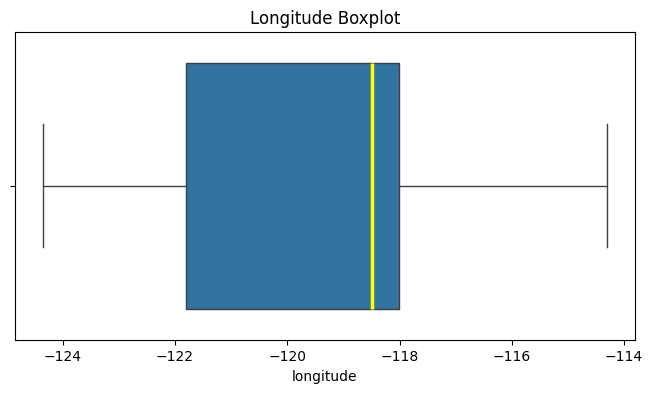

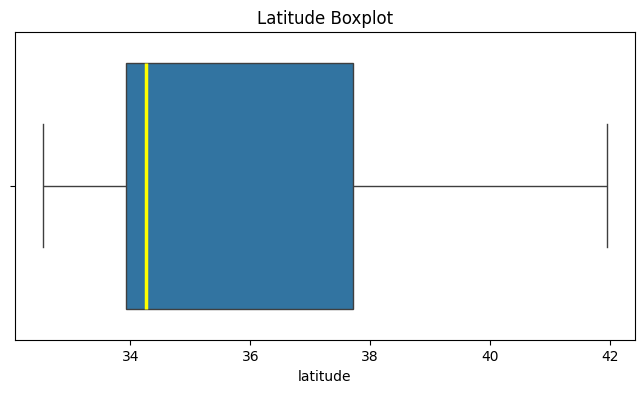

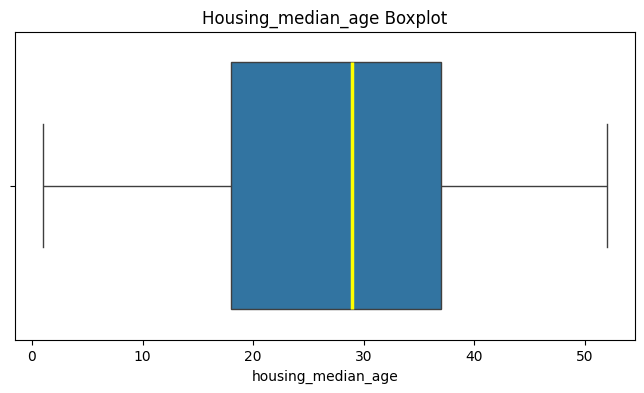

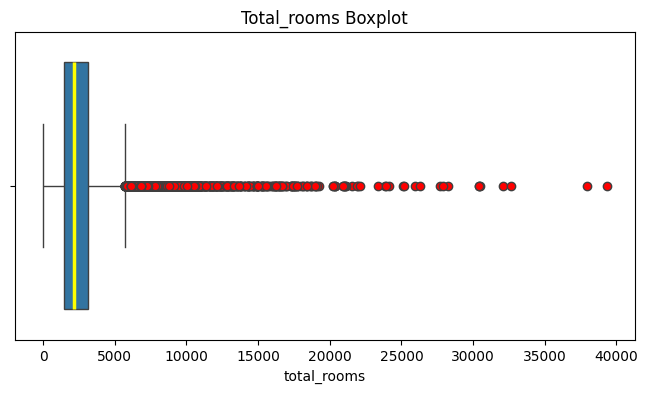

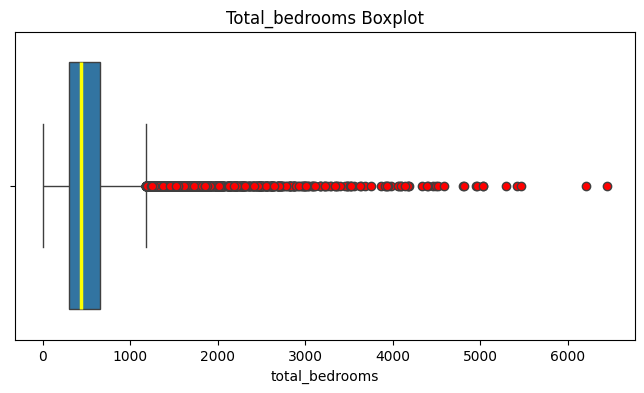

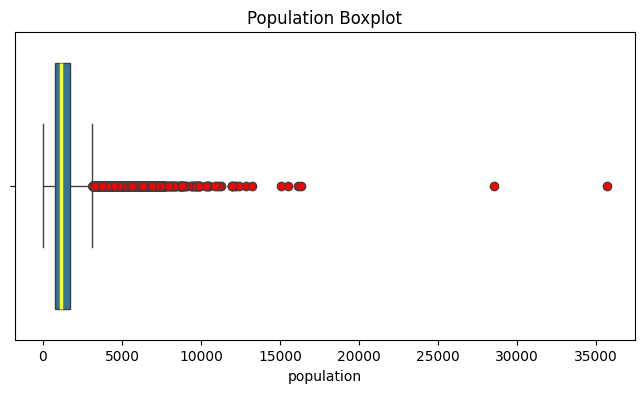

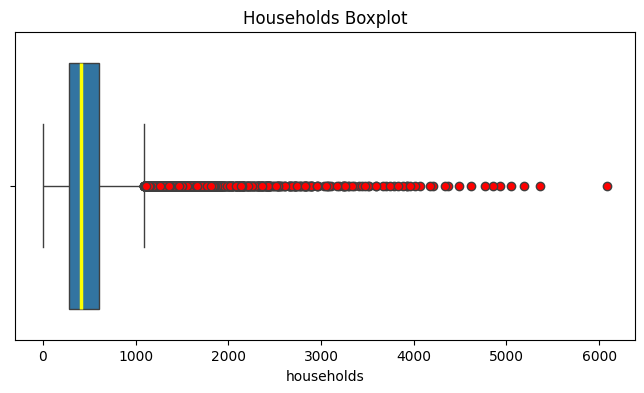

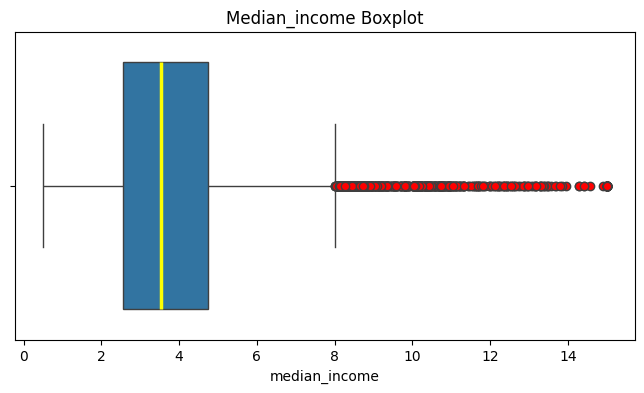

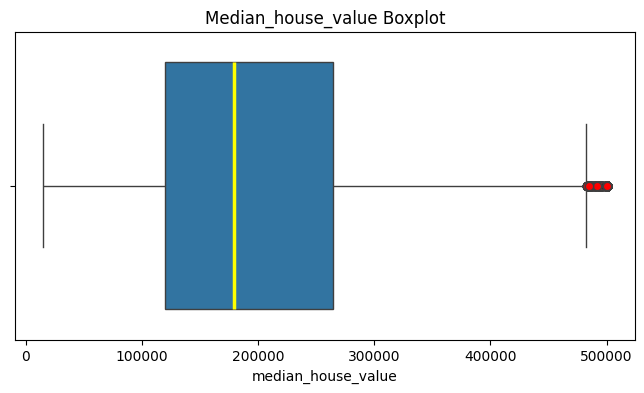

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric column boxplots
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(x=numeric_df[col],
              flierprops={'markerfacecolor':'red'},
              medianprops={'color':'yellow', 'linewidth':2.5})
  plt.title(f'{col.capitalize()} Boxplot')
  plt.show()

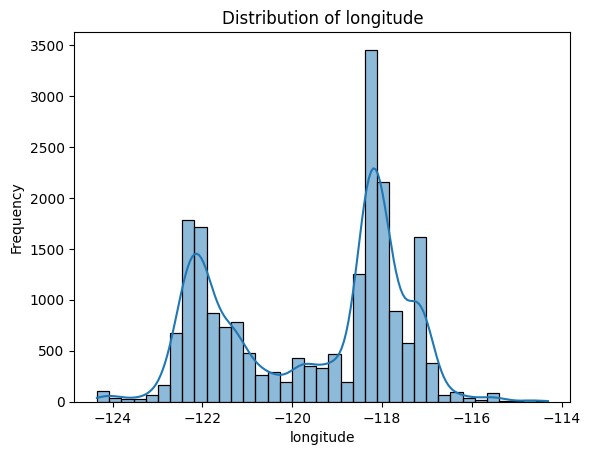

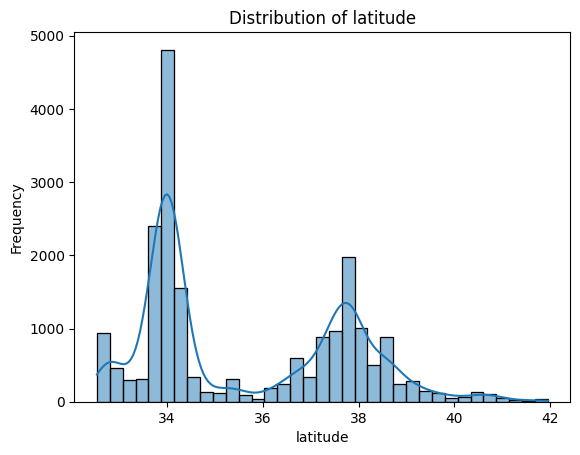

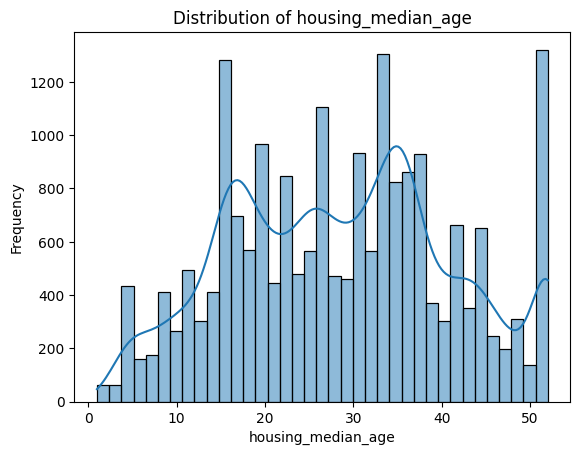

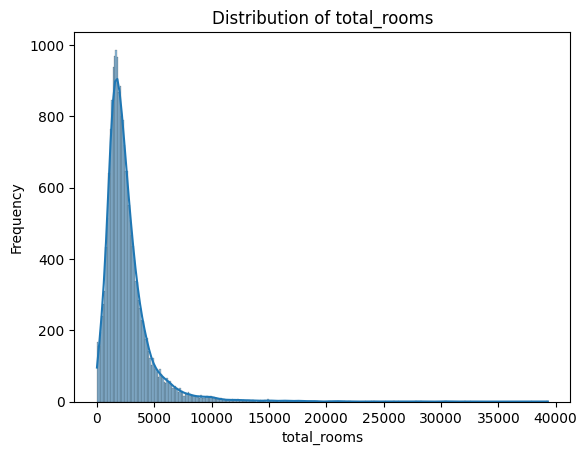

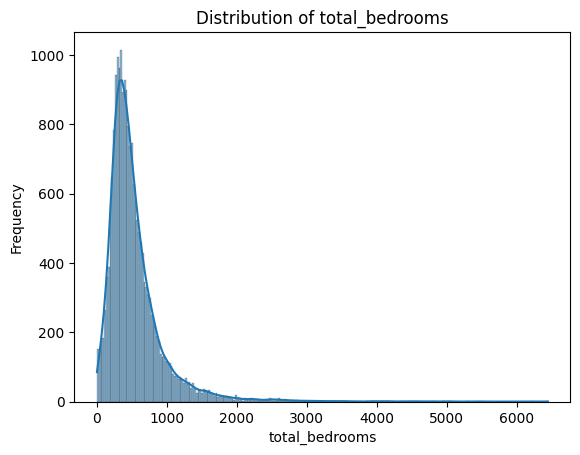

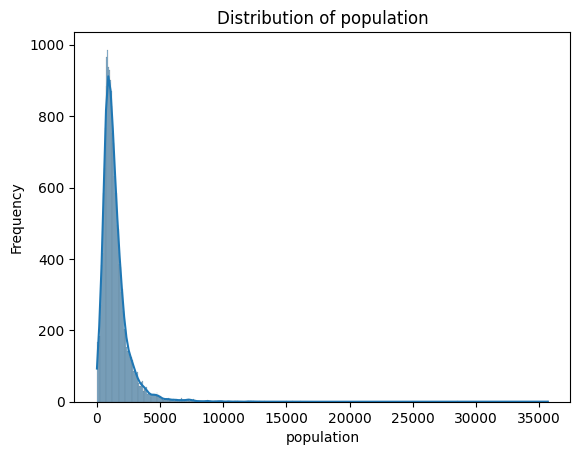

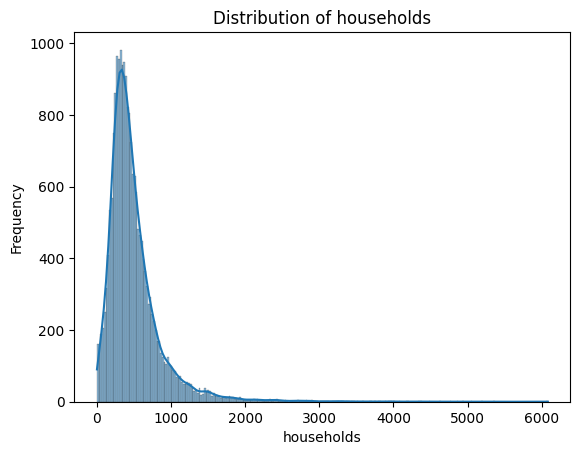

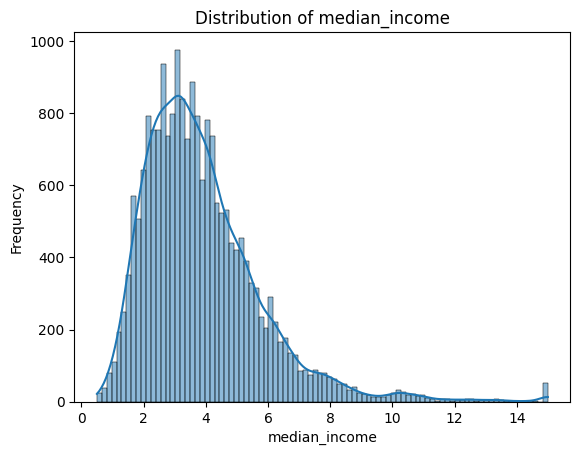

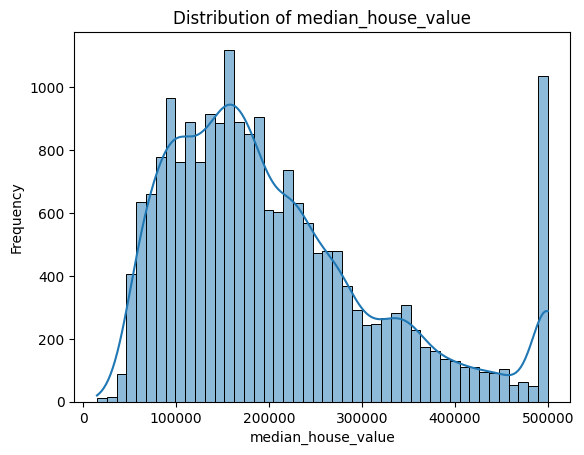

In [ ]:
# numeric histograms
for col in numeric_cols:
  sns.histplot(housing_df[col].dropna(), kde=True)
  plt.title(f'Distribution of {col}')
  plt.ylabel('Frequency')
  plt.show()

In [ ]:
# skewness for numeric cols
skew_df = pd.DataFrame({
    'skewness': numeric_df.skew()
})

In [ ]:
skew_df['skew_desc'] = ''

for i, skew_val in skew_df['skewness'].items():
  if -0.5 < skew_val < -1:
    skew_df.loc[i, 'skew_desc'] = 'moderately left-skewed'
  elif skew_val < -1:
    skew_df.loc[i, 'skew_desc'] = 'highly left-skewed'
  elif 0.5 < skew_val < 1:
    skew_df.loc[i, 'skew_desc'] = 'moderately right-skewed'
  elif 1 < skew_val:
    skew_df.loc[i, 'skew_desc'] = 'highly right-skewed'
  else:
    skew_df.loc[i, 'skew_desc'] = 'approximately symmetric'

#skew_summary = skew_df.sort_values('skewness', ascending=False)
#display(skew_df)
display(skew_df.sort_values('skewness', ascending=False))

,skewness,skew_desc
population,4.935858,highly right-skewed
total_rooms,4.147343,highly right-skewed
total_bedrooms,3.459546,highly right-skewed
households,3.410438,highly right-skewed
median_income,1.646657,highly right-skewed
median_house_value,0.977763,moderately right-skewed
latitude,0.465953,approximately symmetric
housing_median_age,0.060331,approximately symmetric
longitude,-0.297801,approximately symmetric


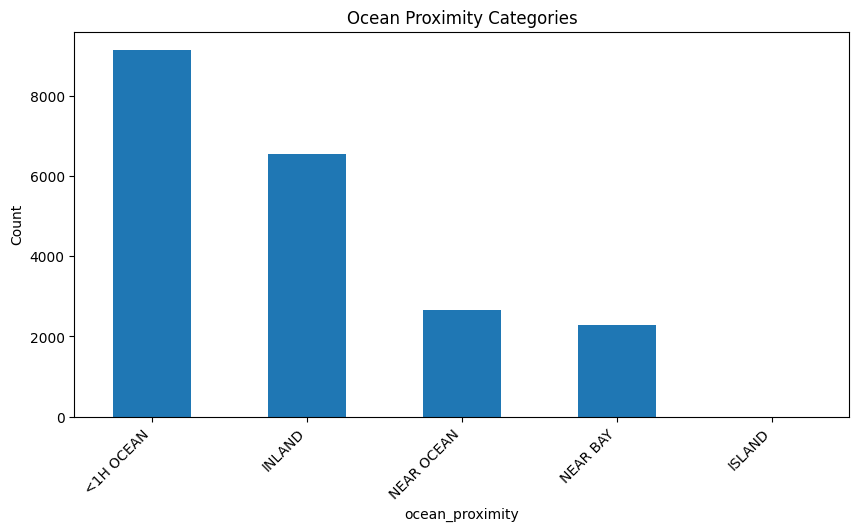

,count,percent
ocean_proximity,,
<1H OCEAN,9136,44.26
INLAND,6551,31.74
NEAR OCEAN,2658,12.88
NEAR BAY,2290,11.09
ISLAND,5,0.02


In [ ]:
# categorical summary
categorical_cols = housing_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
  counts = housing_df[col].value_counts(dropna=False)
  percentages = housing_df[col].value_counts(normalize=True, dropna=False) * 100

  summary = pd.DataFrame({
      'count': counts,
      'percent': percentages
  })

  plt.figure(figsize=(10, 5))
  summary.head(10)['count'].plot(kind='bar')
  plt.title(f'Ocean Proximity Categories')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.show()

display(summary.style.format(precision=2))

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


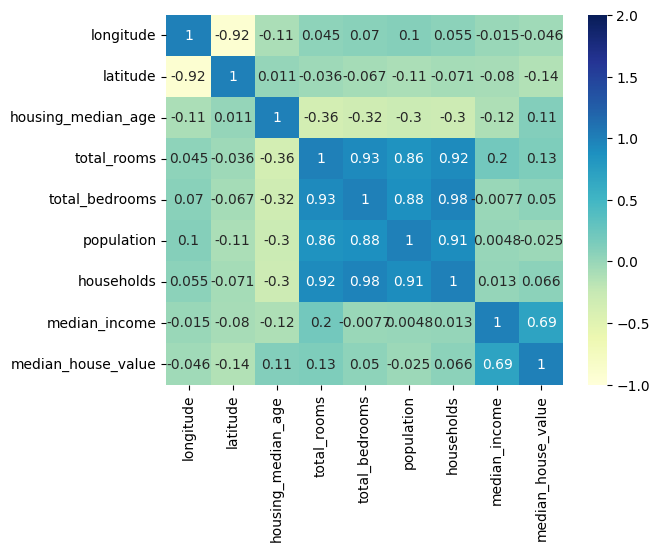

In [ ]:
# correlation: pearson correlation
pearson_corr = numeric_df.corr(method='pearson')
display(pearson_corr)

sns.heatmap(pearson_corr, vmin=-1, vmax=2, cmap='YlGnBu', annot=True)
plt.show()

In [ ]:
# correlation with target
corr_target = pearson_corr[target].sort_values(ascending=False)
display(corr_target)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


In [ ]:
# correlation: chi-square, for categorical col
# ocean_proximity and median_house_value corr
import scipy.stats as sp
from scipy.stats import chi2_contingency
from scipy.stats import chi2

housing_df['price_category'] = pd.qcut(
    housing_df[target],
    q=4,
    labels=['low','medium','high','very high']
)

#contingency table
table = pd.crosstab(housing_df['ocean_proximity'],housing_df['price_category'])

chi2_test_stat, p, dof, expected = sp.chi2_contingency(table)

print(f"Chi-square test between ocean_proximity and {target}")
print(f"Chi-square statistic: {chi2_test_stat:.3f}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")


Chi-square test between ocean_proximity and median_house_value
Chi-square statistic: 7043.505
p-value: 0.0
Degrees of freedom: 12


# Assignment 4

**Data Cleaning**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# load and read dataset
file_path = '/content/drive/MyDrive/housing.csv'

housing_df = pd.read_csv(file_path)

# check
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# set class/target attributte/col
target = 'median_house_value'

# check shape (i.e. # rows and # cols)
housing_df.shape

(20640, 10)

In [ ]:
# identify cols with missing data
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Attribute 'total_bedrooms' has 207 missing data entries

In [ ]:
# check for duplicate rows
print('duplicated rows:', housing_df.duplicated().sum())

duplicated rows: 0


In [ ]:
# remove/drop rows with missing data
missing_dropped_df = housing_df.dropna()

rows_dropped = housing_df.shape[0] - missing_dropped_df.shape[0]
print('rows dropped:', rows_dropped)

print('before dropping missing data rows:', housing_df.shape)
print('after dropping missing data rows:', missing_dropped_df.shape)

# removed data percentage
percent_lost = round((100*rows_dropped)/float(housing_df.shape[0]))
print(f'{percent_lost}% of rows removed from orignal dataset')

rows dropped: 207
before dropping missing data rows: (20640, 10)
after dropping missing data rows: (20433, 10)
1% of rows removed from orignal dataset


In [ ]:
# compare dataset before and after removing missing values

# before
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# after
missing_dropped_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# change in mean before and after dropping missig data rows
((missing_dropped_df.mean(numeric_only=True) - housing_df.mean(numeric_only=True)) / housing_df.mean(numeric_only=True) * 100).round(2)

,0
longitude,0.00
latitude,0.00
housing_median_age,-0.02
total_rooms,0.03
total_bedrooms,0.00
population,-0.04
households,-0.02
median_income,0.01
median_house_value,0.00


In [ ]:
# find outliers using IQR
Q1 = missing_dropped_df.quantile(0.25, numeric_only=True)
Q3 = missing_dropped_df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
print(IQR)

longitude                  3.7900
latitude                   3.7900
housing_median_age        19.0000
total_rooms             1693.0000
total_bedrooms           351.0000
population               935.0000
households               324.0000
median_income              2.1803
median_house_value    145200.0000
dtype: float64


In [ ]:
# remove outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

numeric_cols = missing_dropped_df.select_dtypes(include='number').columns

missing_outliers_dropped_df = missing_dropped_df[
    ~((missing_dropped_df[numeric_cols] < lower_bound) |
     (missing_dropped_df[numeric_cols] > upper_bound)).any(axis=1)
]

missing_outliers_dropped_df.shape

(17434, 10)

In [ ]:
outlier_rows_dropped = missing_dropped_df.shape[0] - missing_outliers_dropped_df.shape[0]
print('rows dropped:', outlier_rows_dropped)

print('before dropping outlier data rows:', missing_dropped_df.shape)
print('after dropping outlier data rows:', missing_outliers_dropped_df.shape)

# data removed percentage
percent_lost2 = round((100*outlier_rows_dropped)/float(missing_dropped_df.shape[0]))
percent_lost3 = round((100*(rows_dropped + outlier_rows_dropped))/float(housing_df.shape[0]))
print(f'{percent_lost2}% of rows removed from dataset without missing data rows')
print(f'original dataset: {housing_df.shape}')
print(f'{percent_lost3}% of rows removed from orignal dataset')


rows dropped: 2999
before dropping outlier data rows: (20433, 10)
after dropping outlier data rows: (17434, 10)
15% of rows removed from dataset without missing data rows
original dataset: (20640, 10)
16% of rows removed from orignal dataset


In [ ]:
# before removing outliers
missing_dropped_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# after removing outliers
missing_outliers_dropped_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000,17434.000000
mean,-119.605773,35.697862,29.489216,2144.865206,445.472697,1197.108294,416.806126,3.575593,187056.188826
std,2.004422,2.166633,12.214437,1088.703854,221.276085,601.851013,205.412687,1.443540,93742.859159
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.790000,33.940000,19.000000,1377.000000,287.000000,766.250000,271.000000,2.490150,112900.000000
50%,-118.610000,34.310000,30.000000,1979.000000,411.000000,1111.000000,387.000000,3.390600,170100.000000
75%,-118.030000,37.740000,38.000000,2782.000000,578.000000,1559.000000,540.000000,4.487950,241600.000000
max,-114.490000,41.950000,52.000000,5675.000000,1173.000000,3124.000000,1090.000000,8.011300,482200.000000


In [ ]:
# change in mean before and after dropping outlier data rows
print("change in mean before and after dropping outlier data rows from dataset without missing data rows:")
((missing_outliers_dropped_df.mean(numeric_only=True) - missing_dropped_df.mean(numeric_only=True)) / missing_dropped_df.mean(numeric_only=True) * 100).round(2)

change in mean before and after dropping outlier data rows from dataset without missing data rows:


,0
longitude,0.03
latitude,0.18
housing_median_age,2.99
total_rooms,-18.65
total_bedrooms,-17.18
population,-15.99
households,-16.54
median_income,-7.64
median_house_value,-9.58


In [ ]:
print("change in mean before and after dropping outlier data rows from original dataset:")
((missing_outliers_dropped_df.mean(numeric_only=True) - housing_df.mean(numeric_only=True)) / housing_df.mean(numeric_only=True) * 100).round(2)

change in mean before and after dropping outlier data rows from original dataset:


,0
longitude,0.03
latitude,0.19
housing_median_age,2.97
total_rooms,-18.62
total_bedrooms,-17.18
population,-16.02
households,-16.56
median_income,-7.62
median_house_value,-9.57


In [ ]:
missing_outliers_dropped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17434 entries, 2 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17434 non-null  float64
 1   latitude            17434 non-null  float64
 2   housing_median_age  17434 non-null  float64
 3   total_rooms         17434 non-null  float64
 4   total_bedrooms      17434 non-null  float64
 5   population          17434 non-null  float64
 6   households          17434 non-null  float64
 7   median_income       17434 non-null  float64
 8   median_house_value  17434 non-null  float64
 9   ocean_proximity     17434 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.5+ MB


In [ ]:
housing_cleaned = missing_outliers_dropped_df

'''
from google.colab import files

housing_cleaned.to_csv("housing_cleaned.csv", index=False)
files.download("housing_cleaned.csv")
'''


'\nfrom google.colab import files\n\nhousing_cleaned.to_csv("housing_cleaned.csv", index=False)\nfiles.download("housing_cleaned.csv")\n'

**Data Transformation**

In [ ]:
# Split the features and target (Model should use features to predict the target)
X = housing_cleaned.drop("median_house_value", axis=1)
y = housing_cleaned["median_house_value"]

# Split column types into categorical and numerical
categorical_features = ["ocean_proximity"]

numerical_features = [
    "longitude", "latitude",
    "housing_median_age",
    "total_rooms", "total_bedrooms",
    "population", "households",
    "median_income"
]

In [ ]:
# Using sklearn to implement data transformation
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Using StandardScaler to scale all numerical columns to be comparable
# Using OneHotEncoder to convert text to numbers
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# The transformed numeric dataset ready for ML
X_transformed = preprocessor.fit_transform(x)

In [ ]:
# Splitting the data into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Cleaned Data (Human View)
housing_cleaned.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


In [ ]:
# Transformed Data (Machine View)
pd.DataFrame(x_transformed).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.314246,0.993339,1.843018,-0.622653,-1.154576,-1.164953,-1.167469,2.550613,0.0,0.0,0.0,1.0,0.0
1,-1.319235,0.993339,1.843018,-0.799933,-0.951204,-1.061935,-0.962997,1.432289,0.0,0.0,0.0,1.0,0.0
2,-1.319235,0.993339,1.843018,-0.475685,-0.747832,-1.050304,-0.768261,0.187466,0.0,0.0,0.0,1.0,0.0
3,-1.319235,0.993339,1.843018,-1.126018,-1.050630,-1.302865,-1.089575,0.319507,0.0,0.0,0.0,1.0,0.0
4,-1.319235,0.988723,1.843018,0.358358,0.196716,-0.171324,0.473177,0.057851,0.0,0.0,0.0,1.0,0.0


The data is now ready to be used to train and test the model. x_train and y_train is to be used together to train the model while x_test and y_test is to used to test it.